In [1]:
import numpy as np
import copy
import time
from collections import deque
from scipy.optimize import linear_sum_assignment
from scipy.sparse import csr_matrix
from atommover.utils.move_utils import Move
from atommover.utils.AtomArray import AtomArray
from atommover.algorithms.Algorithm_class import Algorithm


In [19]:
def generate_cost_matrix(current_positions, target_positions):
    num_atoms = len(current_positions)
    num_targets = len(target_positions)
    cost_matrix = np.zeros((num_atoms, num_targets))

    for i, current in enumerate(current_positions):
        for j, target in enumerate(target_positions):
            cost_matrix[i, j] = np.sqrt((current[0] - target[0])**2 + (current[1] - target[1])**2)
    return cost_matrix
def move_atom_and_show_grid(grid, start, end):
    #Initialize current position
    current_pos = start
    path = []
    
    while current_pos != end:
        path, current_pos = bfs_move_atom(grid, current_pos, end, path)
        
    path = flatten_tuple(path)[::-1]
    grid, path = generate_decomposed_move_set(grid, path)

    return path
def bfs_move_atom(grid, start, end, prev_path):
    queue = deque([(start[0], start[1], [(start[0], start[1])])]) #Use the queue to record current position and path
    visited = set() #Record the visited positions
    visited.add((start[0], start[1]))

    #Start finding the path
    while queue:
        current_row, current_col, path = queue.popleft() #Update current position

        #If we arrive end point, return the path
        if (current_row, current_col) == end:
            if len(prev_path) > 0:
                prev_path = prev_path, path
            else:
                prev_path = path

            return prev_path, end

        #Explore the next step (based on current position and end point)
        len_path = len(path) - 1
        dr = 1 if end[0] > path[len_path][0] else (-1 if end[0] < path[len_path][0] else 0) 
        dc = 1 if end[1] > path[len_path][1] else (-1 if end[1] < path[len_path][1] else 0)
        new_row, new_col = current_row + dr, current_col + dc

        #Check if there is an obstacle there (If no, start from this new point to find next step)
        if (new_row, new_col) not in visited and grid[new_row][new_col] == 0:
            visited.add((new_row, new_col))
            queue.append((new_row, new_col, path + [(new_row, new_col)])) 

    #If there is an obstacle on the path, we decompose the path: start->obstacle->target
    #Define the obstacle position
    obstacle = (path[len_path][0] + dr, path[len_path][1] + dc)

    # Update the move in path until obstacle
    if len(prev_path) > 0:
        prev_path = prev_path, path + [obstacle]
    else:
        prev_path = path + [obstacle]

    #[Path between start and obstacle] + [Path between obstacle and end]
    return prev_path, obstacle
def flatten_tuple(nested_tuple):
    # This function will flatten a nested tuple of lists into a single tuple of lists
    result = []
    
    def recursive_flatten(element):
        if isinstance(element, tuple):
            # If the element is a tuple, apply recursion to each item
            for item in element:
                recursive_flatten(item)
        elif isinstance(element, list):
            # If the element is a list, append it to the result
            result.append(tuple(element))

    # Start the recursion with the entire nested tuple
    recursive_flatten(nested_tuple)
    
    # Convert the list of tuples into a single tuple
    return tuple(result)

    left_eject, bot_eject, top_eject, right_eject = [], [], [], []
    len_x = len(matrix[0])
    len_y = len(matrix)
    for x in range(len_x):
        for y in range(len_y):
            if matrix[x][y] == 1 and target_config[x][y] == 0:
                if x >= y and x < len_y - y:
                    left_eject.append((x, y))
                elif x >= y and x >= len_y - y:
                    bot_eject.append((x, y))
                elif x < y and x <= len_y - y:
                    top_eject.append((x, y))
                elif x <= y and x >= len_y - y:
                    right_eject.append((x, y))
    return left_eject, bot_eject, top_eject, right_eject
def generate_decomposed_move_set(grid, path):
    decomposed_move_set = []

    #Iterate all path segments (((a1,b1), (a2,b2), (a3, b3), (a4,b4)), ((c1,d1), (c2,d2)))
    try:
        for segmant in path:
            from_row, from_col = segmant[0]
            for coordinate in segmant:
                to_row, to_col = coordinate
                # To exclude the frist move
                if from_row != to_row or from_col != to_col:
                    decomposed_move_set.append([Move(from_row, from_col, to_row, to_col)])
                    grid[from_row][from_col] = 0
                    grid[to_row][to_col] = 1
                    from_row, from_col = to_row, to_col
            # decomposed_move_set.append(segmant_moves)
    except IndexError:
        return grid, []
        
    return grid, decomposed_move_set
def define_current_and_target(matrix, target_config):
    current_positions = [(x, y) for x in range(len(matrix[0])) for y in range(len(matrix)) if matrix[x][y] == 1 if target_config[x][y] == 0] #NKH this should in theory not change anything...
    target_positions = [(x, y) for x in range(len(matrix[0])) for y in range(len(matrix)) if target_config[x][y] == 1 if matrix[x][y] == 0] #same here
    return current_positions, target_positions


In [23]:
def Hungarian_algorithm_original(atom_arrays: np.ndarray, target_config: np.ndarray, do_ejection: bool = False, final_size: list = []):
    time_1 = time.time()
    move_set = []
    matrix = copy.deepcopy(atom_arrays)

    if len(final_size) == 0:
        final_size = [0, len(matrix[0])-1, 0, len(matrix)-1]

    current_positions, target_positions = define_current_and_target(matrix, target_config)    #Define target positions for the center square in a matrix.
    time_2 = time.time()
    print(f"Defining current and target positions took {time_2 - time_1} seconds.")   
    cost_matrix = generate_cost_matrix(current_positions, target_positions)    # Generate the cost matrix using the current atom positions and the target positions
    time_3 = time.time()
    print(f"Generating cost matrix took {time_3 - time_2} seconds.")
    row_ind, col_ind = linear_sum_assignment(cost_matrix)    # row_ind and col_ind are arrays of indices indicating the optimal assignment
    time_4 = time.time()
    print(f"Solving linear sum assignment took {time_4 - time_3} seconds.")                     
    paired_indices = sorted(zip(row_ind, col_ind), key=lambda x: x[1])    # Pair up row_ind and col_ind and sort by col_ind

    if paired_indices:
        # Unzip the sorted pairs if paired_indices is not empty
        sorted_row_ind, sorted_col_ind = zip(*paired_indices)
    else:
        # Assign default values if paired_indices is empty
        sorted_row_ind, sorted_col_ind = [], []
    prepared_assignments = [(current_positions[i], target_positions[j]) for i, j in zip(sorted_row_ind, sorted_col_ind)]

    for start, target in prepared_assignments:
        Hungarian_move = []
        Hungarian_move = move_atom_and_show_grid(matrix, start, target)
        move_set.extend(Hungarian_move)

    #Optional ejection argument
    if do_ejection:
        eject_moves, eject_config = ejection(matrix, target_config, final_size)
        move_set.extend(eject_moves)
    else:
        eject_config = copy.deepcopy(matrix)

    success_flag = Algorithm.get_success_flag(eject_config.reshape(np.shape(target_config)), target_config, do_ejection=do_ejection, n_species = 1)
    time_5 = time.time()    
    print(f"returning the results took {time_5 - time_4} seconds.")      
    print(f"Total time for Hungarian algorithm: {time_5 - time_1} seconds.")                      
    return eject_config, move_set, success_flag,time_2-time_1,time_3-time_2,time_4-time_3,time_5-time_4    

In [ ]:
import time
from atommover.utils import PhysicalParams
from atommover.utils import AtomArray      
from atommover.algorithms import Hungarian
 

# Start timing
start_time = time.time()

# specifying parameters
load_prob = 0.5 # float; the probability that an individual site will be loaded
array_length = 100 # int; number of rows (or cols) of the square array

params = PhysicalParams(loading_prob = load_prob)

init_start = time.time()
atom_array_1 = AtomArray([array_length, array_length], 1, params)
init_time = time.time() - init_start
print(f"Array initialization time: {init_time:.4f} seconds")

load_start = time.time()
atom_array_1.load_tweezers()
load_time = time.time() - load_start
print(f"Tweezer loading time: {load_time:.4f} seconds")

# Time target generation
target_start = time.time()
atom_array_1.generate_target()
target_time = time.time() - target_start
print(f"Target generation time: {target_time:.4f} seconds")

# Time move calculation
moves_start = time.time()
eject_config, move_sequence, success_flag, defining_time, generating_cost_matrix_time, solving_time, decomposing_time = Hungarian_algorithm_original(atom_array_1.matrix[:,:,0], atom_array_1.target)
moves_time = time.time() - moves_start
print(f"Move sequence calculation time: {moves_time:.4f} seconds")

# Total time
total_time = time.time() - start_time
print(f"\nTotal execution time: {total_time:.4f} seconds")
print(f"Number of moves: {len(move_sequence) if move_sequence else 0}")
print(move_sequence)
print(move_sequence[1][0].from_row)

Array initialization time: 0.0006 seconds
Tweezer loading time: 0.0007 seconds
Target generation time: 0.0003 seconds
Defining current and target positions took 0.04723715782165527 seconds.
Generating cost matrix took 15.286817789077759 seconds.
Solving linear sum assignment took 1.6194241046905518 seconds.
returning the results took 0.04408431053161621 seconds.
Total time for Hungarian algorithm: 16.997563362121582 seconds.
Move sequence calculation time: 17.0015 seconds

Total execution time: 17.0040 seconds
Number of moves: 4337
[[(0, 2) -> (0, 3)], [(0, 13) -> (0, 14)], [(0, 14) -> (0, 15)], [(0, 12) -> (0, 13)], [(1, 17) -> (0, 18)], [(0, 18) -> (0, 19)], [(1, 19) -> (0, 20)], [(0, 20) -> (0, 21)], [(0, 24) -> (0, 25)], [(0, 25) -> (0, 26)], [(0, 26) -> (0, 27)], [(0, 23) -> (0, 24)], [(0, 24) -> (0, 25)], [(0, 22) -> (0, 23)], [(0, 27) -> (0, 28)], [(0, 28) -> (0, 29)], [(1, 25) -> (0, 26)], [(0, 26) -> (0, 27)], [(0, 32) -> (0, 31)], [(0, 38) -> (0, 37)], [(0, 42) -> (0, 41)], [

In [ ]:
# ...existing code...
import os
import time
import io
import contextlib
import numpy as np
import pandas as pd
from atommover.utils import PhysicalParams, AtomArray

# benchmark settings
array_lengths = [3, 6, 10, 18, 32, 56, 100]
trials = 50
load_prob = 0.5

os.makedirs("./time_test_data", exist_ok=True)
results = []

for L in array_lengths:
    params = PhysicalParams(loading_prob=load_prob)
    target_times = []
    defining_times = []
    generating_times = []
    solving_times = []
    decomposing_times = []

    for _ in range(trials):
        atom_array = AtomArray([L, L], 1, params)
        atom_array.load_tweezers()

        # measure target generation time (ms)
        t0 = time.time()
        atom_array.generate_target()
        target_times.append((time.time() - t0) * 1000.0)

        # run Hungarian_algorithm_original and capture returned timing components, suppressing stdout
        buf = io.StringIO()
        with contextlib.redirect_stdout(buf):
            res = Hungarian_algorithm_original(atom_array.matrix[:, :, 0], atom_array.target)
        # res: (eject_config, move_set, success_flag, defining_time, generating_cost_matrix_time, solving_time, decomposing_time)
        _, _, _, defining_t, generating_t, solving_t, decomposing_t = res

        defining_times.append(defining_t * 1000.0)
        generating_times.append(generating_t * 1000.0)
        solving_times.append(solving_t * 1000.0)
        decomposing_times.append(decomposing_t * 1000.0)

    # aggregate mean and variance (ms)
    results.append({
        "array_length": L,
        "target_time_mean_ms": np.mean(target_times),
        "target_time_var_ms": np.var(target_times, ddof=0),
        "defining_time_mean_ms": np.mean(defining_times),
        "defining_time_var_ms": np.var(defining_times, ddof=0),
        "generating_cost_matrix_time_mean_ms": np.mean(generating_times),
        "generating_cost_matrix_time_var_ms": np.var(generating_times, ddof=0),
        "solving_time_mean_ms": np.mean(solving_times),
        "solving_time_var_ms": np.var(solving_times, ddof=0),
        "decomposing_time_mean_ms": np.mean(decomposing_times),
        "decomposing_time_var_ms": np.var(decomposing_times, ddof=0),
    })

df = pd.DataFrame(results)
csv_path = "./time_test_data/hungarian_time_stats.csv"
xlsx_path = "./time_test_data/hungarian_time_stats.xlsx"
df.to_csv(csv_path, index=False)
# df.to_excel(xlsx_path, index=False)

print(f"Saved: {csv_path} and {xlsx_path}")
# ...existing code...

ModuleNotFoundError: No module named 'openpyxl'

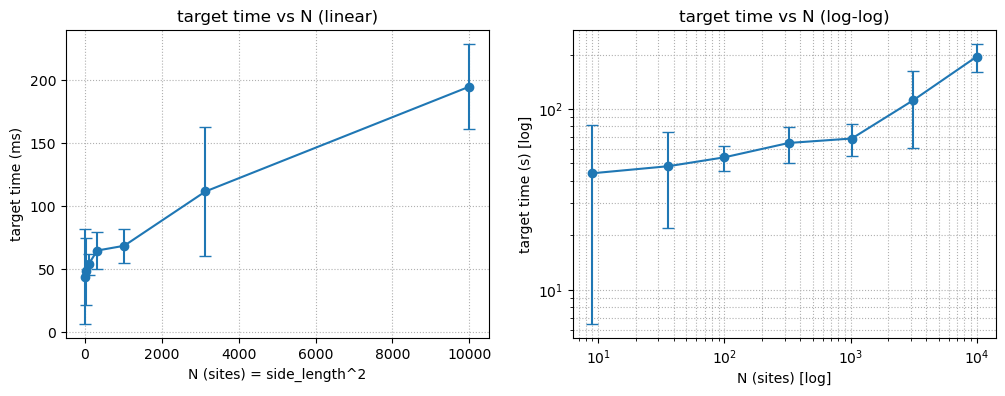

Saved: ./time_test_data/target_time_vs_N.png


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import os

# side lengths and data (means in s, std in s)
side_lengths = np.array([3, 6, 10, 18, 32, 56, 100])
N = side_lengths**2

means = np.array([0.044050217, 0.048208237, 0.053977966, 0.06483078, 0.068612099, 0.111689568, 0.194907188])*1000
stds  = np.array([0.037614793, 0.026281428, 0.00836275, 0.01435239, 0.01349519, 0.051063543, 0.033720555])*1000

os.makedirs('./time_test_data', exist_ok=True)

fig, axes = plt.subplots(1,2, figsize=(12,4))

# linear-scale plot with error bars
ax = axes[0]
ax.errorbar(N, means, yerr=stds, fmt='o-', capsize=4, markersize=6)
ax.set_xlabel('N (sites) = side_length^2')
ax.set_ylabel('target time (ms)')
ax.set_title('target time vs N (linear)')
ax.grid(True, ls=':')

# log-log plot with error bars
ax = axes[1]
ax.errorbar(N, means, yerr=stds, fmt='o-', capsize=4, markersize=6)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('N (sites) [log]')
ax.set_ylabel('target time (s) [log]')
ax.set_title('target time vs N (log-log)')
ax.grid(True, which='both', ls=':')

out_path = './time_test_data/target_time_vs_N.png'
fig.savefig(out_path, dpi=200, bbox_inches='tight')
plt.show()

print(f"Saved: {out_path}")
plt.show()

In [ ]:
# def compute_positions_and_cost(matrix, target_config):

#     matrix = np.array(matrix)
#     target_config = np.array(target_config)

#     # 找出 current=1,target=0 的点 和 current=0,target=1 的点
#     current_positions = np.argwhere((matrix == 1) & (target_config == 0))
#     target_positions = np.argwhere((target_config == 1) & (matrix == 0))

#     # 计算 cost 矩阵（距离矩阵）
#     # 使用广播实现欧氏距离计算
#     diff = current_positions[:, None, :] - target_positions[None, :, :]
#     cost_matrix = np.linalg.norm(diff, axis=2)
#     return current_positions, target_positions, cost_matrix
def generate_cost_matrix_scipy(current_positions, target_positions):
    # current_positions, target_positions: sequence of (x,y) pairs
    if len(current_positions) == 0 or len(target_positions) == 0:
        return np.zeros((len(current_positions), len(target_positions)))
    A = np.asarray(current_positions, dtype=float)
    B = np.asarray(target_positions, dtype=float)
    from scipy.spatial.distance import cdist
    return cdist(A, B, metric='euclidean')
def generate_cost_matrix_broadcast(current_positions, target_positions):
    if len(current_positions) == 0 or len(target_positions) == 0:
        return np.zeros((len(current_positions), len(target_positions)))
    A = np.asarray(current_positions, dtype=float)   # shape (n,2)
    B = np.asarray(target_positions, dtype=float)    # shape (m,2)
    diff = A[:, None, :] - B[None, :, :]             # shape (n,m,2)
    return np.sqrt((diff * diff).sum(axis=2))        # shape (n,m)

from numba import njit, prange
@njit(parallel=True)
def _gen_cost_numba(A, B):
    n = A.shape[0]; m = B.shape[0]
    out = np.empty((n, m), dtype=np.float64)
    for i in prange(n):
        for j in range(m):
            dx = A[i,0] - B[j,0]
            dy = A[i,1] - B[j,1]
            out[i,j] = (dx*dx + dy*dy) ** 0.5
    return out
def generate_cost_matrix_numba(current_positions, target_positions):
    if len(current_positions) == 0 or len(target_positions) == 0:
        return np.zeros((len(current_positions), len(target_positions)))
    A = np.asarray(current_positions, dtype=np.float64)
    B = np.asarray(target_positions, dtype=np.float64)
    return _gen_cost_numba(A, B)

import numpy as np

def define_current_and_target_numpy(matrix, target_config):
    matrix = np.asarray(matrix)
    target_config = np.asarray(target_config)

    current_positions = np.argwhere((matrix == 1) & (target_config == 0))
    target_positions  = np.argwhere((target_config == 1) & (matrix == 0))
    return current_positions, target_positions

import numpy as np
from numba import njit

@njit
def define_current_and_target_numba(matrix, target_config):
    ny, nx = matrix.shape
    current_x = []
    current_y = []
    target_x = []
    target_y = []

    for y in range(ny):
        for x in range(nx):
            if matrix[y, x] == 1 and target_config[y, x] == 0:
                current_x.append(x)
                current_y.append(y)
            elif target_config[y, x] == 1 and matrix[y, x] == 0:
                target_x.append(x)
                target_y.append(y)

    current_positions = np.empty((len(current_x), 2), dtype=np.int32)
    target_positions = np.empty((len(target_x), 2), dtype=np.int32)

    for i in range(len(current_x)):
        current_positions[i, 0] = current_x[i]
        current_positions[i, 1] = current_y[i]
    for i in range(len(target_x)):
        target_positions[i, 0] = target_x[i]
        target_positions[i, 1] = target_y[i]

    return current_positions, target_positions

def define_current_and_target(matrix, target_config):
    current_positions = [(x, y) for x in range(len(matrix[0])) for y in range(len(matrix)) if matrix[x][y] == 1 if target_config[x][y] == 0] #NKH this should in theory not change anything...
    target_positions = [(x, y) for x in range(len(matrix[0])) for y in range(len(matrix)) if target_config[x][y] == 1 if matrix[x][y] == 0] #same here
    return current_positions, target_positions



In [113]:
def Hungarian_algorithm_1(atom_arrays: np.ndarray, target_config: np.ndarray, do_ejection: bool = False, final_size: list = []):
    time_1 = time.time()
    move_set = []
    matrix = copy.deepcopy(atom_arrays)

    if len(final_size) == 0:
        final_size = [0, len(matrix[0])-1, 0, len(matrix)-1]

    current_positions, target_positions= define_current_and_target(matrix, target_config)    #Define target positions for the center square in a matrix.
    cost_matrix = generate_cost_matrix_scipy(current_positions, target_positions)    # Generate the cost matrix using the current atom positions and the target positions 
    print(cost_matrix.shape)
    time_3 = time.time()    
    print(f"Generating cost matrix took {time_3 - time_1} seconds.")
    row_ind, col_ind = linear_sum_assignment(cost_matrix)    # row_ind and col_ind are arrays of indices indicating the optimal assignment
    time_4 = time.time()
    print(f"Solving linear sum assignment took {time_4 - time_3} seconds.")                     
    paired_indices = sorted(zip(row_ind, col_ind), key=lambda x: x[1])    # Pair up row_ind and col_ind and sort by col_ind

    if paired_indices:
        # Unzip the sorted pairs if paired_indices is not empty
        sorted_row_ind, sorted_col_ind = zip(*paired_indices)
    else:
        # Assign default values if paired_indices is empty
        sorted_row_ind, sorted_col_ind = [], []
    prepared_assignments = [(current_positions[i], target_positions[j]) for i, j in zip(sorted_row_ind, sorted_col_ind)]

    for start, target in prepared_assignments:
        Hungarian_move = []
        Hungarian_move = move_atom_and_show_grid(matrix, start, target)
        move_set.extend(Hungarian_move)

    #Optional ejection argument
    if do_ejection:
        eject_moves, eject_config = ejection(matrix, target_config, final_size)
        move_set.extend(eject_moves)
    else:
        eject_config = copy.deepcopy(matrix)

    success_flag = Algorithm.get_success_flag(eject_config.reshape(np.shape(target_config)), target_config, do_ejection=do_ejection, n_species = 1)
    time_5 = time.time()    
    print(f"returning the results took {time_5 - time_4} seconds.")      
    print(f"Total time for Hungarian algorithm: {time_5 - time_1} seconds.")                      
    return eject_config, move_set, success_flag,time_3-time_1,time_4-time_3,time_5-time_4 

In [126]:
import time
from atommover.utils import PhysicalParams
from atommover.utils import AtomArray      
from atommover.algorithms import Hungarian
 

# Start timing
start_time = time.time()

# specifying parameters
load_prob = 0.5 # float; the probability that an individual site will be loaded
array_length = 32 # int; number of rows (or cols) of the square array

params = PhysicalParams(loading_prob = load_prob)

init_start = time.time()
atom_array_1 = AtomArray([array_length, array_length], 1, params)
init_time = time.time() - init_start
print(f"Array initialization time: {init_time:.4f} seconds")

load_start = time.time()
atom_array_1.load_tweezers()
load_time = time.time() - load_start
print(f"Tweezer loading time: {load_time:.4f} seconds")

# Time target generation
target_start = time.time()
atom_array_1.generate_target()
target_time = time.time() - target_start
print(f"Target generation time: {target_time:.4f} seconds")

# Time move calculation
moves_start = time.time()
eject_config, move_sequence, success_flag,generating_cost_matrix_time, solving_time, decomposing_time\
= Hungarian_algorithm_1(atom_array_1.matrix[:,:,0], atom_array_1.target)
moves_time = time.time() - moves_start
print(f"Move sequence calculation time: {moves_time:.4f} seconds")

# Total time
total_time = time.time() - start_time
print(f"\nTotal execution time: {total_time:.4f} seconds")
print(f"Number of moves: {len(move_sequence) if move_sequence else 0}")
print(move_sequence)
print(move_sequence[1][0].from_row)

Array initialization time: 0.0002 seconds
Tweezer loading time: 0.0004 seconds
Target generation time: 0.0005 seconds
(272, 284)
Generating cost matrix took 0.004150390625 seconds.
Solving linear sum assignment took 0.008278131484985352 seconds.
returning the results took 0.006200551986694336 seconds.
Total time for Hungarian algorithm: 0.018629074096679688 seconds.
Move sequence calculation time: 0.0191 seconds

Total execution time: 0.0217 seconds
Number of moves: 447
[[(0, 1) -> (0, 2)], [(0, 2) -> (0, 3)], [(0, 0) -> (0, 1)], [(1, 9) -> (0, 9)], [(2, 10) -> (1, 11)], [(1, 11) -> (0, 12)], [(0, 12) -> (0, 13)], [(1, 13) -> (0, 14)], [(0, 14) -> (0, 15)], [(0, 18) -> (0, 17)], [(1, 19) -> (0, 19)], [(0, 23) -> (0, 22)], [(0, 22) -> (0, 21)], [(1, 25) -> (0, 24)], [(0, 24) -> (0, 23)], [(0, 26) -> (0, 25)], [(0, 28) -> (0, 27)], [(2, 0) -> (1, 0)], [(2, 2) -> (1, 2)], [(2, 4) -> (1, 4)], [(1, 7) -> (1, 6)], [(3, 9) -> (2, 10)], [(2, 10) -> (1, 11)], [(1, 11) -> (1, 12)], [(1, 17) -> (